# Ephemeris Data for Mars and the Sun

This notebook computes a daily ephemeris—i.e., a table of celestial positions—for **Mars** and the **Sun** as observed from **Earth**.  
It is part of a series of notebooks illustrating Keplerian analysis to determine Mars' orbit using observational data from Earth.

**Contact:** Luca.Canali@cern.ch  
**Date:** February 2025

---
## Overview

We use **NASA JPL's DE421 ephemeris** via the **Skyfield** library to generate accurate planetary positions over a period of 12 Martian years (approximately **22 Earth years**), starting from January 1, 2000. The key objectives of this notebook are:

- **Compute Orbital Positions**  
  - Determine the **ecliptic longitude** of Mars and the Sun in the plane of Earth's orbit.
  
- **Filter for Visibility Near Solar Conjunction**  
  - Calculate the **angular separation** between Mars and the Sun.  
  - Remove data points where Mars is obscured by the Sun’s glare (i.e., when their angular separation is below a threshold).

- **Export Data for Further Analysis**  
  - Save the filtered ephemeris data into a **CSV file** (`ephemeris_mars_sun.csv`).
  - Key attributes in the saved data are: Date, Mars Ecliptic Longitude (deg), Sun Ecliptic Longitude (deg)

- **Visualize Orbital Motion**  
  - Generate plots using **Matplotlib** to illustrate how Mars' ecliptic longitude changes over time.  
  - Highlight periods when Mars is visible in the night sky.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skyfield.api import load
from datetime import datetime

# Load JPL DE421 ephemeris data
eph = load('de421.bsp')
earth, mars, sun = eph['earth'], eph['mars'], eph['sun']
ts = load.timescale()

# Define parameters
start_date = datetime(2000, 1, 1)
mars_year_days = 687      # Mars' orbital period in Earth days
num_years = 12            # Number of Mars years to cover
total_days = mars_year_days * num_years

# Generate a daily date range for the entire period
dates = pd.date_range(start=start_date, periods=total_days + 1, freq='D')
years = dates.year.to_numpy()
months = dates.month.to_numpy()
days = dates.day.to_numpy()

# Create a Skyfield times object using vectorized inputs
t = ts.utc(years, months, days)


In [2]:
# Compute the apparent positions as seen from Earth
mars_astrometric = earth.at(t).observe(mars).apparent()
sun_astrometric  = earth.at(t).observe(sun).apparent()

# Convert the positions to ecliptic coordinates (latitude, longitude, distance)
mars_eclip_lat, mars_eclip_lon, _ = mars_astrometric.ecliptic_latlon()
sun_eclip_lat,  sun_eclip_lon,  _ = sun_astrometric.ecliptic_latlon()

# Create a DataFrame holding the ecliptic longitude for Mars and the Sun
df = pd.DataFrame({
    "Date": dates,
    "Mars Ecliptic Longitude (deg)": mars_eclip_lon.degrees,
    "Sun Ecliptic Longitude (deg)": sun_eclip_lon.degrees
})


In [3]:
# -------------------------------
# Filter for night-time visibility of Mars
# -------------------------------
# Define a threshold (in degrees) to consider Mars as sufficiently far from the Sun.
threshold_sep = 15.0  # degrees (adjust as needed)

# Compute angular separation between Mars and the Sun in ecliptic longitude,
# accounting for the cyclic nature of angles (wrap-around at 360°)
angular_sep = np.abs(mars_eclip_lon.degrees - sun_eclip_lon.degrees)
angular_sep = np.minimum(angular_sep, 360 - angular_sep)

# Determine night-time visibility: True if Mars is sufficiently separated from the Sun
visible_at_night = angular_sep >= threshold_sep

# Create a DataFrame with all the computed data
df = pd.DataFrame({
    "Date": dates,
    "Mars Ecliptic Longitude (deg)": mars_eclip_lon.degrees,
    "Sun Ecliptic Longitude (deg)": sun_eclip_lon.degrees,
    "Angular Separation (deg)": angular_sep,
    "Visible at Night": visible_at_night
})

# Create a DataFrame that only includes points where Mars is visible at night
df_night = df[df["Visible at Night"]].copy()

df_night

,Date,Mars Ecliptic Longitude (deg),Sun Ecliptic Longitude (deg),Angular Separation (deg),Visible at Night
0,2000-01-01,327.579360,279.863105,47.716254,True
1,2000-01-02,328.354992,280.882498,47.472494,True
2,2000-01-03,329.130637,281.901969,47.228668,True
3,2000-01-04,329.906278,282.921499,46.984779,True
4,2000-01-05,330.681896,283.941064,46.740832,True
...,...,...,...,...,...
8240,2022-07-24,42.511853,120.797689,78.285836,True
8241,2022-07-25,43.175979,121.752899,78.576920,True
8242,2022-07-26,43.837769,122.708329,78.870561,True
8243,2022-07-27,44.497171,123.663977,79.166806,True


In [4]:
# Save the DataFrame with Mars and Sun positions, when Mars is visible in the night sky, to a CSV file

folder = "../Data/"
csv_filename = "ephemeris_mars_sun.csv"

df_night.to_csv(folder+csv_filename, index=False)
#df.to_csv(csv_filename, index=False)
print(f"Ephemeris data successfully saved to {csv_filename}")

Ephemeris data successfully saved to ephemeris_mars_sun.csv


## Optionally plot the computed data

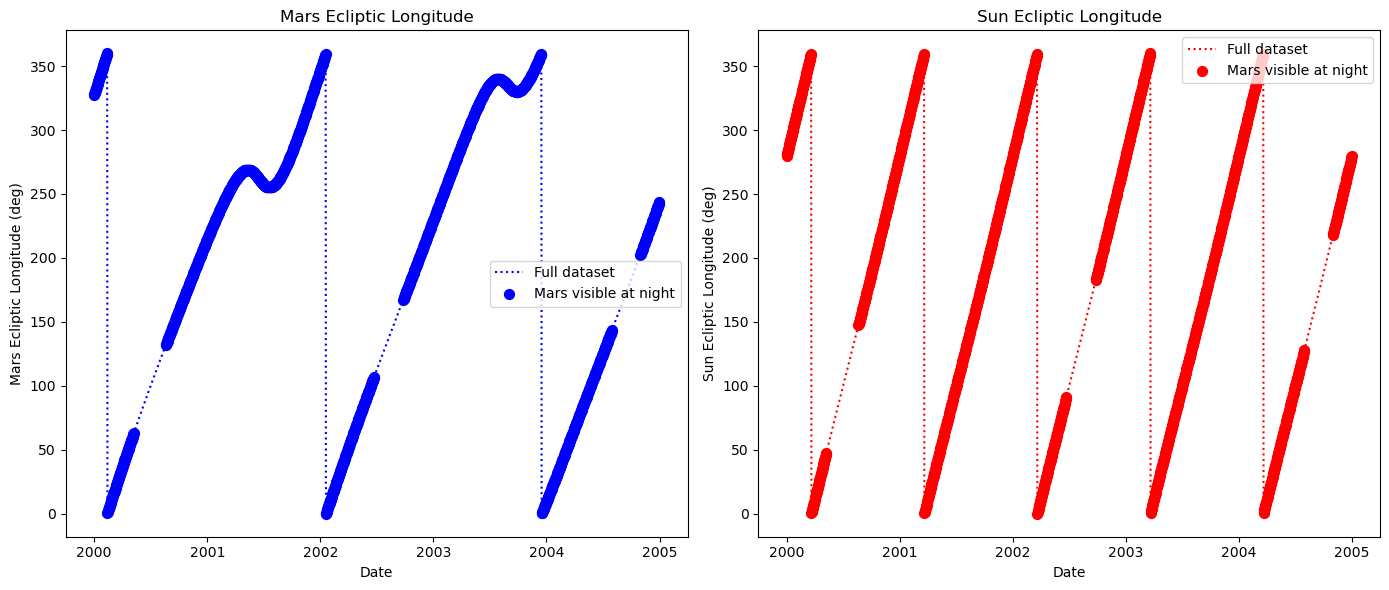

Plotting a subset of the data


In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Configurable parameter: number of years to plot (set to 5)
n_years = 5

# Ensure 'Date' columns are datetime for both DataFrames
df['Date'] = pd.to_datetime(df['Date'])
df_night['Date'] = pd.to_datetime(df_night['Date'])

# Define the start and end dates based on the first n_years
start_date = df['Date'].iloc[0]
end_date = start_date + pd.DateOffset(years=n_years)

# Filter the data for the first n_years
filtered_df = df[(df['Date'] >= start_date) & (df['Date'] < end_date)]
filtered_night_df = df_night[(df_night['Date'] >= start_date) & (df_night['Date'] < end_date)]

# Create two subplots: left for Mars Ecliptic Longitude, right for Sun Ecliptic Longitude
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# -----------------------------
# Mars Ecliptic Longitude Plot (Left)
# -----------------------------
# Plot full dataset as a dotted line
ax1.plot(filtered_df['Date'], filtered_df['Mars Ecliptic Longitude (deg)'], linestyle=':', color='blue', label='Full dataset')
# Overlay night-only data as larger dots
ax1.scatter(filtered_night_df['Date'], filtered_night_df['Mars Ecliptic Longitude (deg)'], color='blue', s=50, label='Mars visible at night')
ax1.set_xlabel("Date")
ax1.set_ylabel("Mars Ecliptic Longitude (deg)")
ax1.set_title("Mars Ecliptic Longitude")
ax1.legend()

# -----------------------------
# Sun Ecliptic Longitude Plot (Right)
# -----------------------------
# Plot full dataset as a dotted line
ax2.plot(filtered_df['Date'], filtered_df['Sun Ecliptic Longitude (deg)'], linestyle=':', color='red', label='Full dataset')
# Overlay night-only data as larger dots
ax2.scatter(filtered_night_df['Date'], filtered_night_df['Sun Ecliptic Longitude (deg)'], color='red', s=50, label='Mars visible at night')
ax2.set_xlabel("Date")
ax2.set_ylabel("Sun Ecliptic Longitude (deg)")
ax2.set_title("Sun Ecliptic Longitude")
ax2.legend()

plt.tight_layout()
plt.show()

print("Plotting a subset of the data")
